В данной лабораторной работе используются данные, рекомендованные в презентации: База для тренировки:
 https://drive.google.com/open?id=1OXZ-7SKtOKZJh6ta1jOocd2ZPLWHRCTZ
https://drive.google.com/open?id=1wI3rNJ4ii1wkvZ0l5sobKBYJsXPS-hX6

Мой вариант - SVM классификатор

In [1]:
import pandas as pd
import numpy as np
import os
import zipfile
import pickle
import librosa
import warnings
warnings.filterwarnings('ignore')

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

from tqdm import tqdm

np.random.seed(42)

import seaborn as sns
import matplotlib.pyplot as plt

1. Распаковка данных

In [5]:


zip_path = 'D:\\ЦОС_2 семестр\\AED_lab\\audio_train.zip'
csv_path = 'train.csv'
extract_folder = 'audio_files'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)

df = pd.read_csv(csv_path)
print(f"\nЗагружено {len(df)} записей из CSV.")
print(f"Уникальных классов: {df['label'].nunique()}")


print(df['label'].value_counts())


Загружено 5683 записей из CSV.
Уникальных классов: 41
                      fname              label
0  8bcbcc394ba64fe85ed4.wav    Finger_snapping
1  00d77b917e241afa06f1.wav             Squeak
2  17bb93b73b8e79234cb3.wav     Electric_piano
3  7d5c7a40a936136da55e.wav          Harmonica
4  17e0ee7565a33d6c2326.wav         Snare_drum
5  2d2900e792da5d4f6ab2.wav            Trumpet
6  6464a45df1b76196be09.wav  Computer_keyboard
Fart                     195
Flute                    194
Double_bass              191
Trumpet                  188
Acoustic_guitar          187
Cello                    186
Shatter                  184
Applause                 183
Bass_drum                181
Gong                     180
Hi-hat                   180
Fireworks                180
Saxophone                179
Clarinet                 176
Laughter                 174
Snare_drum               173
Squeak                   171
Violin_or_fiddle         167
Cough                    163
Tearing           

In [6]:
print(df.head(7))

                      fname              label
0  8bcbcc394ba64fe85ed4.wav    Finger_snapping
1  00d77b917e241afa06f1.wav             Squeak
2  17bb93b73b8e79234cb3.wav     Electric_piano
3  7d5c7a40a936136da55e.wav          Harmonica
4  17e0ee7565a33d6c2326.wav         Snare_drum
5  2d2900e792da5d4f6ab2.wav            Trumpet
6  6464a45df1b76196be09.wav  Computer_keyboard


2. Извлечение признаков

1) MFCC:
    
    - средние значения MFCC
    
    - стандартные отклонения MFCC
    
    - средние значения дельт MFCC (скорость изменения)
    

In [22]:
def extract_mfcc(file_path, n_mfcc=13):

    try:
        y, sr = librosa.load(file_path, sr=None)

        mfcc = librosa.feature.mfcc(
            y=y,
            sr=sr,
            n_mfcc=n_mfcc
        )

        mfcc_mean = np.mean(mfcc, axis=1)
        mfcc_std = np.std(mfcc, axis=1)

        features = np.concatenate([mfcc_mean, mfcc_std])

        return features

    except Exception as e:
        print(f"Ошибка файла {file_path}: {e}")
        return None

In [24]:
features = []
labels = []

audio_folder = r"D:\ЦОС_2 семестр\AED_lab\train"

for idx, row in tqdm(df.iterrows(), total=len(df)):

    file_name = row['fname']
    label = row['label']

    file_path = os.path.join(audio_folder, file_name)

    mfcc_features = extract_mfcc(file_path)

    if mfcc_features is not None:
        features.append(mfcc_features)
        labels.append(label)

100%|██████████████████████████████████████████████████████████████████████████████| 5683/5683 [02:27<00:00, 38.64it/s]


In [25]:
X = np.array(features)
y = np.array(labels)

print("Размер X:", X.shape)
print("Размер y:", y.shape)

Размер X: (5683, 26)
Размер y: (5683,)


In [26]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [27]:
print(le.classes_)

['Acoustic_guitar' 'Applause' 'Bark' 'Bass_drum' 'Burping_or_eructation'
 'Bus' 'Cello' 'Chime' 'Clarinet' 'Computer_keyboard' 'Cough' 'Cowbell'
 'Double_bass' 'Drawer_open_or_close' 'Electric_piano' 'Fart'
 'Finger_snapping' 'Fireworks' 'Flute' 'Glockenspiel' 'Gong'
 'Gunshot_or_gunfire' 'Harmonica' 'Hi-hat' 'Keys_jangling' 'Knock'
 'Laughter' 'Meow' 'Microwave_oven' 'Oboe' 'Saxophone' 'Scissors'
 'Shatter' 'Snare_drum' 'Squeak' 'Tambourine' 'Tearing' 'Telephone'
 'Trumpet' 'Violin_or_fiddle' 'Writing']


In [32]:
data = {
    "X": X,
    "y": y_encoded,
    "label_encoder": le
}


In [34]:
print(type(X))
print(type(y_encoded))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [33]:
import joblib

joblib.dump(data, "mfcc_features.pkl")

['mfcc_features.pkl']

In [36]:
# Правильный способ загрузки
data = joblib.load("mfcc_features.pkl")

print(data["X"].shape)

(5683, 26)


Разделение выборки: 20% оставим на тест

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Обучение SVM

Метрика точности непоказательна, так как не наблюдается баланса классов.
Нужно считать F1, но на данном этапе не получилось из-за несоответствия длин y и предсказанного y.

Для подсчета f1 и улучшения результатов выделим валидационное подмножество и переберем параметры SVM

In [87]:
# train+val и test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# train и val
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,  # Здесь должны быть train_val, а не X, y!
    test_size=0.2,
    random_state=42,
    stratify=y_train_val
)

In [88]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf"))
])

In [89]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('svm', SVC())])

In [93]:
y_train_pred = pipeline.predict(X_train)
y_val_pred = pipeline.predict(X_val)
y_test_pred = pipeline.predict(X_test)

# Подсчет метрик
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score

print("=== F1 scores (macro) ===")
print(f"F1 train: {f1_score(y_train, y_train_pred, average='macro'):.4f}")
print(f"F1 val: {f1_score(y_val, y_val_pred, average='macro'):.4f}")
print(f"F1 test: {f1_score(y_test, y_test_pred, average='macro'):.4f}")


=== F1 scores (macro) ===
F1 train: 0.6764
F1 val: 0.5004
F1 test: 0.5153


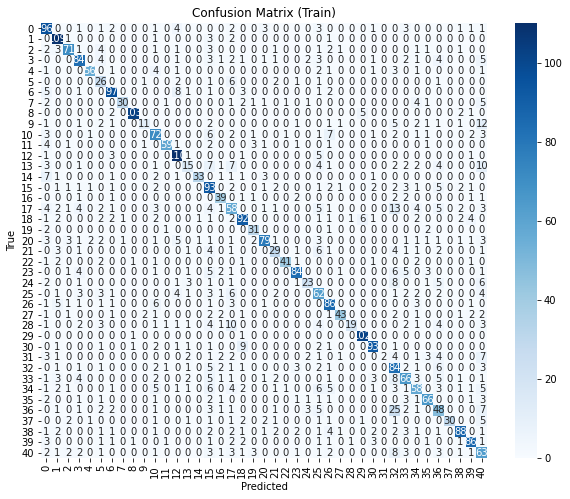

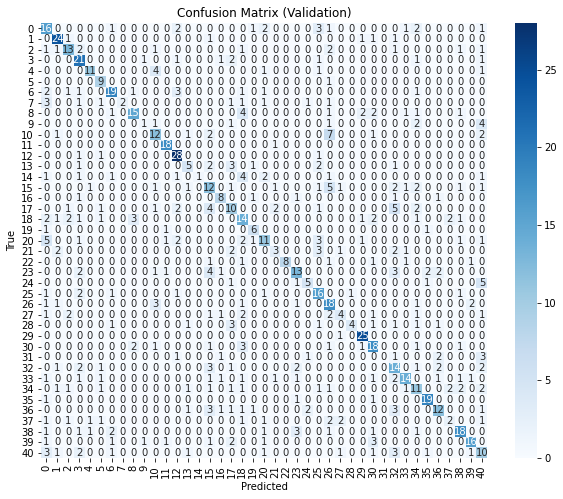

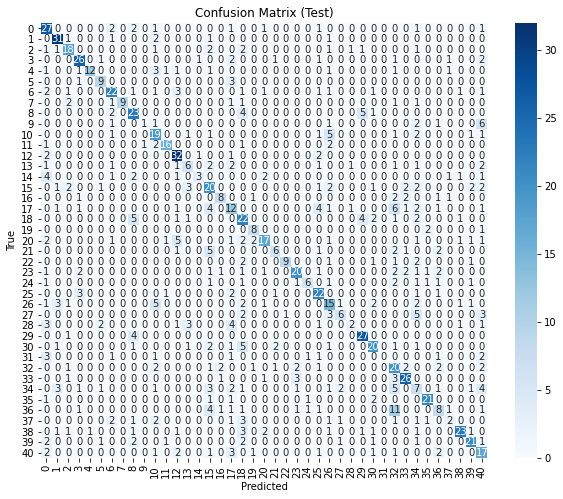

In [94]:

# Матрица для train
cm_train = confusion_matrix(y_train, y_train_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm_train, cmap="Blues", annot=True, fmt='d')
plt.title("Confusion Matrix (Train)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Матрица для validation
cm_val = confusion_matrix(y_val, y_val_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm_val, cmap="Blues", annot=True, fmt='d')
plt.title("Confusion Matrix (Validation)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Матрица для test
cm_test = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm_test, cmap="Blues", annot=True, fmt='d')
plt.title("Confusion Matrix (Test)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

GridSearch: перебор параметров SVM

In [95]:
param_grid = {
    "svm__C": [0.1, 1, 10],
    "svm__gamma": ["scale", 0.01, 0.001]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1
)

grid.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('svm', SVC())]),
             n_jobs=-1,
             param_grid={'svm__C': [0.1, 1, 10],
                         'svm__gamma': ['scale', 0.01, 0.001]},
             scoring='f1_macro')

In [96]:
print("Best params:", grid.best_params_)

Best params: {'svm__C': 10, 'svm__gamma': 'scale'}


In [97]:
best_model = grid.best_estimator_

y_train_pred = best_model.predict(X_train)
y_val_pred = best_model.predict(X_val)
y_test_pred = best_model.predict(X_test)

In [98]:
print(f"F1 train (optimized): {f1_score(y_train, y_train_pred, average='macro'):.4f}")
print(f"F1 val (optimized): {f1_score(y_val, y_val_pred, average='macro'):.4f}")
print(f"F1 test (optimized): {f1_score(y_test, y_test_pred, average='macro'):.4f}")

F1 train (optimized): 0.9439
F1 val (optimized): 0.5459
F1 test (optimized): 0.5552


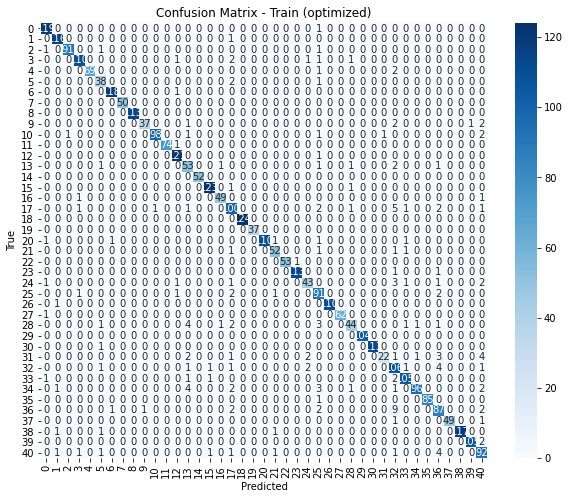

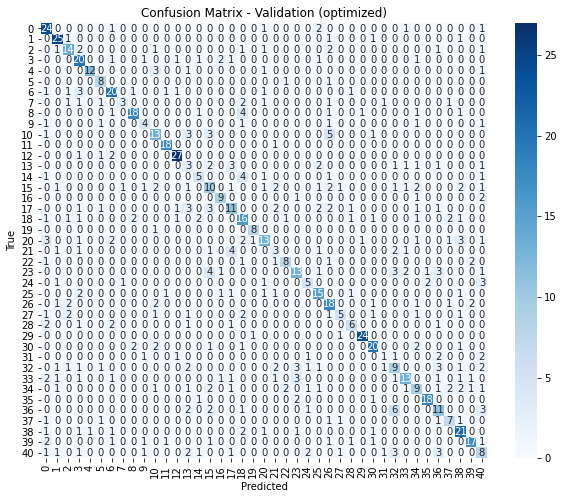

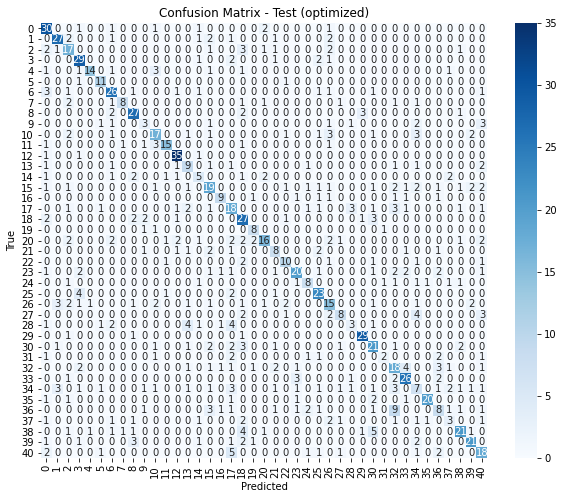

In [100]:
# Train confusion matrix
cm_train = confusion_matrix(y_train, y_train_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm_train, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix - Train (optimized)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Validation confusion matrix
cm_val = confusion_matrix(y_val, y_val_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm_val, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix - Validation (optimized)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Test confusion matrix
cm_test = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm_test, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix - Test (optimized)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [78]:
"""
Выводы

Метрика F1 сначала, после обучения SVM приняла значение:
F1 train: 0.6764
F1 val: 0.5004
F1 test: 0.5153

а после перебора параметров SVM (GridSearch) немного улучшилась на тестовом и валидационном множестве и выросла на трейновом:
F1 train (optimized): 0.9439 - модель подстроилась под обучающую выборку
F1 val (optimized): 0.5459
F1 test (optimized): 0.5552
После перебора парамеиров, похоже, произошло переобучение. 
На новые данные модель плохо обобщается: "понимает" только те данные, на которых ее учили

"""

'\nВыводы\n\nМетрика F1 сначала приняла значение:\n'